### Project By- Pranali for DASA TECHNOWORLD PVT. LTD.

# Demand Forecasting

## Objective

The objective of this notebook is to forecast future farm sales demand using historical sales transactions.

The notebook includes:

- Time-series feature engineering
- Training multiple regression models
- Model comparison
- Future demand forecasting
- Model saving

In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style("whitegrid")

In [2]:
# Load data
sales = pd.read_excel(
    "../data/raw/CLOLINE_Client_Project_Data.xlsx",
    sheet_name="Sales"
)

sales['Sale_Date'] = pd.to_datetime(sales['Sale_Date'])
sales = sales.sort_values('Sale_Date')
print("Dataset Shape :", sales.shape)
display(sales.head())

Dataset Shape : (45000, 6)


,Sale_ID,Farmer_ID,Sale_Type,Quantity,Revenue_INR,Sale_Date
20174,920174,113841,Eggs,1953,328659,2022-12-18
18329,918329,111799,Eggs,920,42208,2022-12-18
18474,918474,114770,Live_Bird,557,227062,2022-12-18
25151,925151,117740,Eggs,346,248218,2022-12-18
9247,909247,110650,Live_Bird,1698,392469,2022-12-18


In [3]:
# Create lag features
sales['lag_1'] = sales['Quantity'].shift(1)
sales['lag_7'] = sales['Quantity'].shift(7)
sales['lag_14'] = sales['Quantity'].shift(14)

# Rolling features
sales['rolling_mean_7'] = sales['Quantity'].rolling(7).mean()
sales['rolling_mean_14'] = sales['Quantity'].rolling(14).mean()

# Date-based features
sales['month'] = sales['Sale_Date'].dt.month
sales['day'] = sales['Sale_Date'].dt.day
sales['weekday'] = sales['Sale_Date'].dt.weekday

# Drop NA rows created due to lagging
sales = sales.dropna().reset_index(drop=True)
sales.head()

,Sale_ID,Farmer_ID,Sale_Type,Quantity,Revenue_INR,Sale_Date,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,month,day,weekday
0,940673,101882,Live_Bird,2346,359404,2022-12-18,4809.0,3104.0,1953.0,3140.714286,2558.500000,12,18,6
1,935156,108184,Live_Bird,395,107749,2022-12-18,2346.0,4862.0,920.0,2502.571429,2521.000000,12,18,6
2,936418,119774,Eggs,872,74984,2022-12-18,395.0,2160.0,557.0,2318.571429,2543.500000,12,18,6
3,922566,117381,Live_Bird,1524,105379,2022-12-18,872.0,3583.0,346.0,2024.428571,2627.642857,12,18,6
4,927946,113406,Live_Bird,2799,382170,2022-12-18,1524.0,3689.0,1698.0,1897.285714,2706.285714,12,18,6


In [4]:
# One-hot encode categorical columns
sales = pd.get_dummies(sales, drop_first=True)

# Convert EVERYTHING to numeric
sales = sales.apply(pd.to_numeric, errors='coerce')

# Replace infinite values
sales.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop remaining NaN rows
sales.dropna(inplace=True)

print("Data types after cleaning:")
print(sales.dtypes)

Data types after cleaning:
Sale_ID                  int64
Farmer_ID                int64
Quantity                 int64
Revenue_INR              int64
Sale_Date                int64
lag_1                  float64
lag_7                  float64
lag_14                 float64
rolling_mean_7         float64
rolling_mean_14        float64
month                    int32
day                      int32
weekday                  int32
Sale_Type_Live_Bird       bool
dtype: object


In [5]:
# Train-Test_Split
train_size = int(len(sales) * 0.8)
train = sales.iloc[:train_size]
test = sales.iloc[train_size:]

X_train = train.drop(columns=['Sale_Date', 'Quantity'], errors='ignore')
y_train = train['Quantity']

X_test = test.drop(columns=['Sale_Date', 'Quantity'], errors='ignore')
y_test = test['Quantity']

In [6]:
X_train, X_test = X_train.align(X_test, join='left', axis=1)
X_test.fillna(0, inplace=True)

,Sale_ID,Farmer_ID,Revenue_INR,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,month,day,weekday,Sale_Type_Live_Bird
35988,915856,119542,509985,1274.0,2366.0,3107.0,1596.142857,2322.428571,5,14,2,False
35989,901105,118078,436304,3229.0,3245.0,4895.0,1169.428571,1991.214286,5,14,2,False
35990,918609,118962,232979,258.0,388.0,2849.0,1386.285714,1923.857143,5,14,2,True
35991,929669,107838,504476,1906.0,757.0,4689.0,1938.857143,1919.285714,5,14,2,True
35992,922965,114171,564806,4625.0,2056.0,417.0,2084.142857,2109.000000,5,14,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...
44981,925240,100655,184431,1668.0,1949.0,355.0,1625.285714,1818.500000,12,17,2,True
44982,918305,117718,597397,387.0,131.0,2925.0,2096.000000,1854.285714,12,17,2,False
44983,939713,117820,423099,3426.0,2258.0,1515.0,2004.285714,1861.500000,12,17,2,True
44984,919284,100128,281657,1616.0,1679.0,3019.0,2271.428571,1899.357143,12,17,2,True


In [7]:
# ============================================================
# Train Regression Models
# ============================================================

models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        random_state=42
    )

}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    r2 = r2_score(y_test, pred)

    results.append({

        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2

    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)

display(results_df)

,Model,MAE,RMSE,R² Score
0,Linear Regression,1077.802319,1281.638879,0.172231
1,Random Forest,1096.007528,1300.866989,0.147207
2,XGBoost,1107.234497,1324.345404,0.116146


In [8]:
# ============================================================
# Select Best Model
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

print("="*60)

print("Best Model :", best_model_name)

Best Model : Linear Regression


In [9]:
# ============================================================
# Final Evaluation
# ============================================================

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("="*60)

print("Demand Forecasting Performance")

print("="*60)

print(f"MAE : {mae:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R² Score : {r2:.4f}")

Demand Forecasting Performance
MAE : 1077.80
RMSE : 1281.64
R² Score : 0.1722


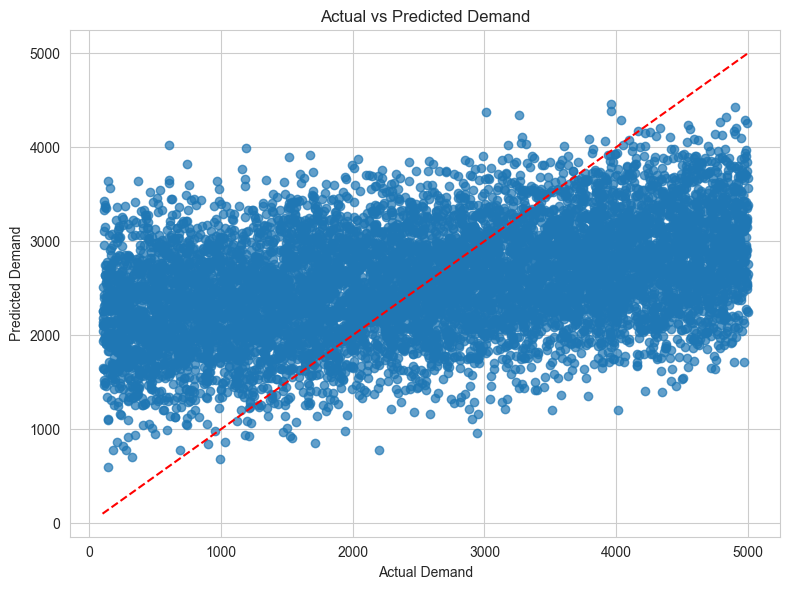

In [10]:
# ============================================================
# Actual vs Predicted
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Demand")

plt.ylabel("Predicted Demand")

plt.title("Actual vs Predicted Demand")

plt.tight_layout()

plt.show()

In [11]:
# Forecast future demand

print("Forecasting Next 6 Days...")
future_steps = 6
last_row = sales.iloc[-1:].copy()

future_predictions = []

for _ in range(future_steps):
    X_future = last_row.drop(['Sale_Date', 'Quantity'], axis=1)
    next_pred = best_model.predict(X_future)[0]
    next_pred = max(next_pred, 0)

    future_predictions.append(next_pred)

    # Shift lag values
    last_row['lag_14'] = last_row['lag_7']
    last_row['lag_7'] = last_row['lag_1']
    last_row['lag_1'] = next_pred

    last_row['rolling_mean_7'] = np.mean(future_predictions[-7:])
    last_row['rolling_mean_14'] = np.mean(future_predictions[-14:])

forecast_df = pd.DataFrame({
    "Forecast_Period": range(1, future_steps + 1),
    "Predicted_Demand": future_predictions
})

display(forecast_df)

Forecasting Next 6 Days...


,Forecast_Period,Predicted_Demand
0,1,1962.766289
1,2,1962.992377
2,3,1970.142506
3,4,1963.874917
4,5,1964.501663
5,6,1964.320505


In [12]:
# save model
joblib.dump(best_model, "../models/demand_forecast.pkl")
print("Demand Forecasting Model Saved Successfully.")

Demand Forecasting Model Saved Successfully.


In [13]:
# Save demand feature columns
demand_feature_columns = list(X_train.columns)

joblib.dump(demand_feature_columns,"../models/demand_feature_columns.pkl")
print("demand_feature_columns.pkl saved successfully")

demand_feature_columns.pkl saved successfully


In [14]:
last_forecast_row = sales.iloc[-1:].copy()
last_forecast_row

,Sale_ID,Farmer_ID,Quantity,Revenue_INR,Sale_Date,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,month,day,weekday,Sale_Type_Live_Bird
44985,935422,107096,1175,202544,1765929600000000,3549.0,1681.0,323.0,2199.142857,1960.214286,12,17,2,False


In [15]:
last_forecast_row = sales.iloc[-1:].copy()

joblib.dump(
    last_forecast_row,
    "../models/forecast_seed.pkl"
)

['../models/forecast_seed.pkl']

# Notebook Conclusion

In this notebook:

- Historical sales data was transformed into a forecasting dataset.
- Time-series lag and rolling features were created.
- Three regression models were compared.
- The best-performing model was selected.
- Future demand was forecasted for the next six periods.
- The trained forecasting model and feature columns were saved for deployment.